# Лекция 8. Вероятностные методы в машинном обучении — демонстрации

Наивный байесовский классификатор, байесовский вывод в линейных моделях, генеративные и дискриминативные подходы.

> Ноутбук сопровождает лекцию: каждый раздел иллюстрирует кодом соответствующий
> теоретический сюжет. Запускайте ячейки по порядку.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({
    "figure.figsize": (7, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

## 1. Наивный байесовский классификатор

$$p(y \mid x) \propto p(y)\prod_{j=1}^{p} p(x_j \mid y).$$

«Наивность» — предположение об условной независимости признаков. Оно почти всегда неверно,
но классификатор работает на удивление хорошо: для верного ответа важен не точный вид
вероятностей, а лишь то, у какого класса апостериорная вероятность больше.

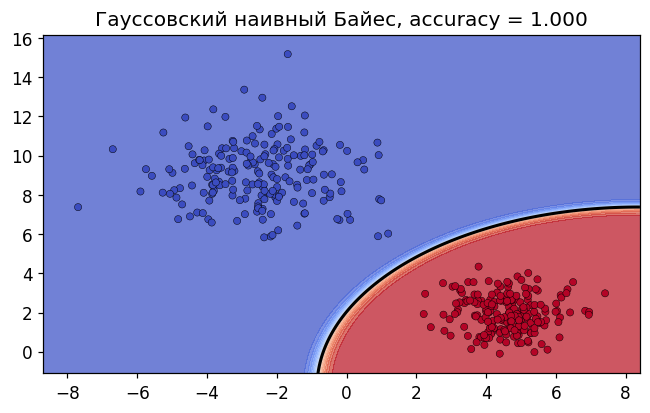

Априорные вероятности классов: [0.5 0.5]


In [2]:
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import make_blobs

Xn, yn = make_blobs(n_samples=400, centers=2, cluster_std=[1.6, 0.9], random_state=RANDOM_STATE)
nb = GaussianNB().fit(Xn, yn)

xx, yy = np.meshgrid(np.linspace(Xn[:, 0].min() - 1, Xn[:, 0].max() + 1, 300),
                     np.linspace(Xn[:, 1].min() - 1, Xn[:, 1].max() + 1, 300))
Z = nb.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=20, cmap="coolwarm", alpha=0.75)
plt.contour(xx, yy, Z, levels=[0.5], colors="k", linewidths=2)
plt.scatter(Xn[:, 0], Xn[:, 1], c=yn, cmap="coolwarm", s=22, edgecolor="k", linewidth=0.3)
plt.title(f"Гауссовский наивный Байес, accuracy = {nb.score(Xn, yn):.3f}")
plt.grid(False)
plt.show()

print("Априорные вероятности классов:", np.round(nb.class_prior_, 3))

## 2. Генеративная модель против дискриминативной

Наивный Байес (генеративный) моделирует $p(x \mid y)$ и делает сильные предположения —
поэтому он **быстро обучается на малых выборках**, но упирается в потолок.
Логистическая регрессия (дискриминативная) моделирует $p(y \mid x)$ напрямую:
на малых данных проигрывает, на больших выигрывает.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
1 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py", line 1335, in fit
    raise Va

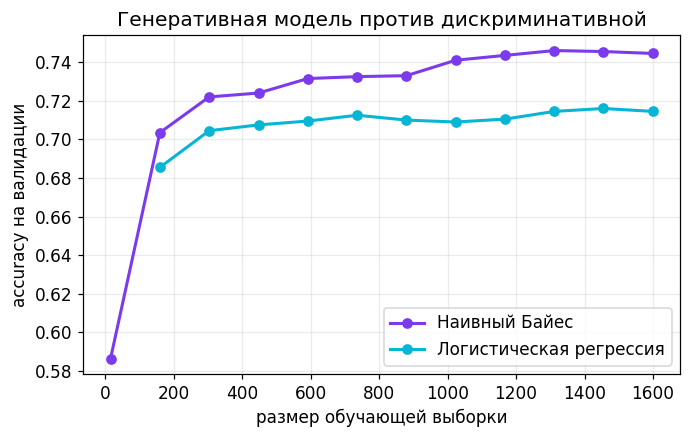

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import learning_curve

Xg, yg = make_classification(n_samples=2000, n_features=20, n_informative=8,
                             random_state=RANDOM_STATE)

for name, model, color in [("Наивный Байес", GaussianNB(), "#7c3aed"),
                           ("Логистическая регрессия", LogisticRegression(max_iter=2000), "#06b6d4")]:
    sizes, _, val = learning_curve(model, Xg, yg, cv=5,
                                   train_sizes=np.linspace(0.01, 1.0, 12), scoring="accuracy")
    plt.plot(sizes, val.mean(axis=1), marker="o", lw=2, color=color, label=name)

plt.xlabel("размер обучающей выборки"); plt.ylabel("accuracy на валидации")
plt.title("Генеративная модель против дискриминативной")
plt.legend()
plt.show()

## 3. Байесовский вывод в линейной регрессии

Вместо точечной оценки весов получаем апостериорное распределение

$$p(w \mid X, y) \propto p(y \mid X, w)\,p(w),$$

а вместе с ним — **честную оценку неопределённости** предсказания.
Заметьте: MAP-оценка с гауссовским априорным распределением $\mathcal{N}(0, \tau^2 I)$
в точности совпадает с гребневой регрессией.

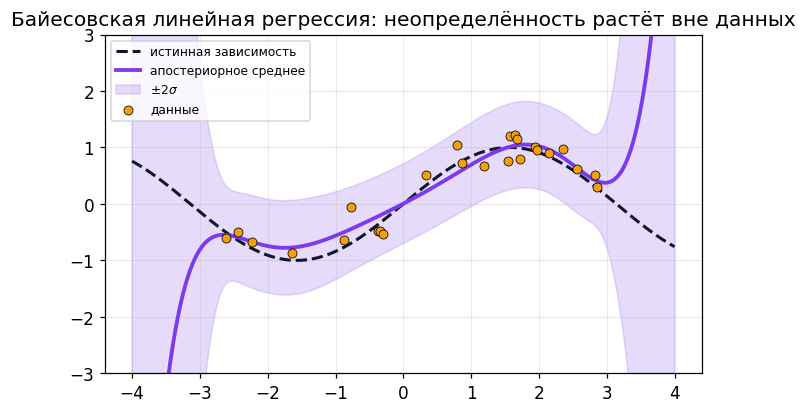

In [4]:
from sklearn.linear_model import BayesianRidge, Ridge

n_obs = 25
X_1d = np.sort(rng.uniform(-3, 3, n_obs)).reshape(-1, 1)
y_1d = np.sin(X_1d).ravel() + rng.normal(0, 0.3, n_obs)

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=7)
Phi = poly.fit_transform(X_1d)

grid = np.linspace(-4, 4, 300).reshape(-1, 1)
Phi_grid = poly.transform(grid)

bayes = BayesianRidge().fit(Phi, y_1d)
mean, std = bayes.predict(Phi_grid, return_std=True)

plt.plot(grid, np.sin(grid), color="#0f172a", ls="--", lw=2, label="истинная зависимость")
plt.plot(grid, mean, color="#7c3aed", lw=2.5, label="апостериорное среднее")
plt.fill_between(grid.ravel(), mean - 2 * std, mean + 2 * std,
                 color="#7c3aed", alpha=0.18, label=r"$\pm 2\sigma$")
plt.scatter(X_1d, y_1d, color="#f59e0b", s=35, zorder=5, edgecolor="k", linewidth=0.5, label="данные")
plt.ylim(-3, 3)
plt.title("Байесовская линейная регрессия: неопределённость растёт вне данных")
plt.legend(fontsize=8)
plt.show()

In [5]:
# MAP с гауссовским априорным = Ridge
ridge = Ridge(alpha=bayes.lambda_ / bayes.alpha_).fit(Phi, y_1d)
print("Совпадение коэффициентов Bayesian MAP и Ridge:")
print("  максимальное расхождение:", np.max(np.abs(ridge.coef_ - bayes.coef_)).round(6))
print(f"  эквивалентная alpha:      {bayes.lambda_ / bayes.alpha_:.4f}")

Совпадение коэффициентов Bayesian MAP и Ridge:
  максимальное расхождение: 0.0
  эквивалентная alpha:      0.8941


## 4. Итоговое сравнение моделей курса

Сведём вместе все семейства, которые разбирались весь семестр.

Наивный Байес              ROC-AUC = 0.9887 ± 0.0056
Логистическая регрессия    ROC-AUC = 0.9953 ± 0.0053


kNN (k=5)                  ROC-AUC = 0.9849 ± 0.0130
SVM (RBF)                  ROC-AUC = 0.9945 ± 0.0060
Решающее дерево            ROC-AUC = 0.9000 ± 0.0368


Случайный лес              ROC-AUC = 0.9895 ± 0.0077


Градиентный бустинг        ROC-AUC = 0.9927 ± 0.0041


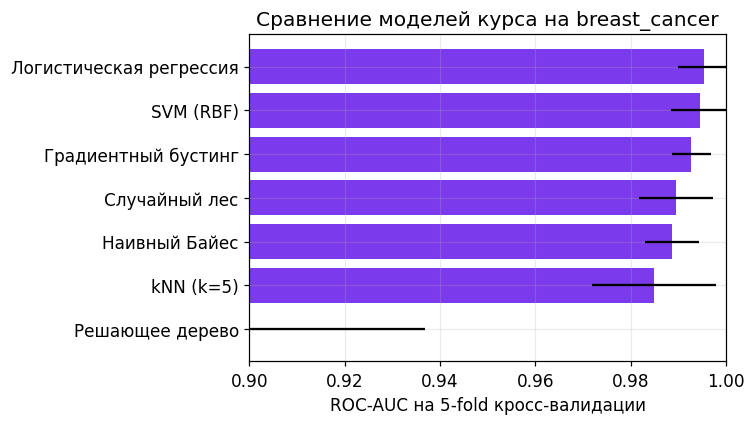

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

data = load_breast_cancer()
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Наивный Байес": GaussianNB(),
    "Логистическая регрессия": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "kNN (k=5)": make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC()),
    "Решающее дерево": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Случайный лес": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Градиентный бустинг": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

names, means, stds = [], [], []
for name, model in models.items():
    scores = cross_val_score(model, data.data, data.target, cv=cv, scoring="roc_auc")
    names.append(name); means.append(scores.mean()); stds.append(scores.std())
    print(f"{name:26s} ROC-AUC = {scores.mean():.4f} ± {scores.std():.4f}")

order = np.argsort(means)
plt.barh(np.array(names)[order], np.array(means)[order],
         xerr=np.array(stds)[order], color="#7c3aed")
plt.xlim(0.9, 1.0)
plt.xlabel("ROC-AUC на 5-fold кросс-валидации")
plt.title("Сравнение моделей курса на breast_cancer")
plt.tight_layout()
plt.show()

**Вывод курса.** Разница между хорошими моделями на «удобном» датасете невелика —
куда важнее корректная методология: честная валидация, отсутствие утечек, осмысленная метрика
и понимание того, какие предположения делает каждая модель.